In [1]:
import torch, transformers, datasets

/Users/timbarvenov/Documents/uam/sem1/uczenie_glebokie_all/uczenie_glebokie/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = datasets.load_dataset("cornell-movie-review-data/rotten_tomatoes")

In [3]:
seed = 42

In [4]:
dataset = datasets.DatasetDict({
    "train": dataset["train"].shuffle(seed=seed).select(range(2000)),
    "validation": dataset["validation"].shuffle(seed=seed).select(range(500)),
    "test": dataset["test"].shuffle(seed=seed).select(range(1000))
})

In [5]:
for split in ["train", "validation", "test"]:
    print(f"\n=== {split.upper()} SAMPLE ===")
    print(dataset[split][0])


=== TRAIN SAMPLE ===
{'text': '. . . plays like somebody spliced random moments of a chris rock routine into what is otherwise a cliche-riddled but self-serious spy thriller .', 'label': 0}

=== VALIDATION SAMPLE ===
{'text': "the filmmaker's heart is in the right place . . .", 'label': 1}

=== TEST SAMPLE ===
{'text': 'unpretentious , charming , quirky , original', 'label': 1}


In [6]:
pretrained_name = "bert-base-uncased"
tokenizer = transformers.BertTokenizerFast.from_pretrained(pretrained_name)

In [7]:
MAX_LEN = 128

In [8]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

In [9]:
dataset = dataset.map(tokenize_batch, batched=True)

In [10]:
columns = ["input_ids", "attention_mask", "label"]

for split in ["train", "validation", "test"]:
    dataset[split].set_format(type="torch", columns=columns)

In [11]:
train_loader = torch.utils.data.DataLoader(dataset["train"], batch_size=8, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset["validation"], batch_size=16)
test_loader = torch.utils.data.DataLoader(dataset["test"], batch_size=16)

In [12]:
from tqdm.auto import tqdm
import os

In [13]:
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)
            optimizer.zero_grad()
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            logits = outputs.logits
            total_loss += loss.item() * input_ids.size(0)
            preds = torch.argmax(logits, dim=-1).long()
            total_correct += (preds == labels.long()).sum().item()
            total += input_ids.size(0)
    avg_loss = total_loss / total
    acc = total_correct / total
    return avg_loss, acc


def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    total = 0

    for batch in tqdm(dataloader, desc="train"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)
        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        loss = outputs.loss
        loss.backward()
        # optional grad clipping
        # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

        total += 1
    return total_loss / total

In [14]:
model = transformers.BertForSequenceClassification.from_pretrained(
    pretrained_name,
    num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [15]:
device = torch.device("mps")
model.to(device)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [16]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

In [17]:
num_epochs = 5
num_training_steps = num_epochs * len(train_loader)
num_warmup_steps = int(0.1 * num_training_steps)

In [18]:
scheduler = transformers.get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps
)

In [19]:
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": []}
ckpt_dir = "checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, device)
    # scheduler.step(val_acc)  # LR scheduler keyed on val_acc

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        ckpt_path = os.path.join(ckpt_dir, f"best_model.pt")
        torch.save({
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "val_acc": val_acc,
        }, ckpt_path)
        print("Saved new best checkpoint:", ckpt_path)

evaluating: 100%|██████████| 32/32 [00:03<00:00,  8.51it/s]


Epoch 1: train_loss=0.5556, val_loss=0.3687, val_acc=0.8440
Saved new best checkpoint: checkpoints/best_model.pt


evaluating: 100%|██████████| 32/32 [00:03<00:00,  9.43it/s]


Epoch 2: train_loss=0.2785, val_loss=0.3585, val_acc=0.8560
Saved new best checkpoint: checkpoints/best_model.pt


evaluating: 100%|██████████| 32/32 [00:03<00:00,  9.43it/s]


Epoch 3: train_loss=0.1323, val_loss=0.4371, val_acc=0.8480


evaluating: 100%|██████████| 32/32 [00:03<00:00,  9.31it/s]


Epoch 4: train_loss=0.0578, val_loss=0.5207, val_acc=0.8580
Saved new best checkpoint: checkpoints/best_model.pt


evaluating: 100%|██████████| 32/32 [00:03<00:00,  9.41it/s]

Epoch 5: train_loss=0.0355, val_loss=0.5272, val_acc=0.8540


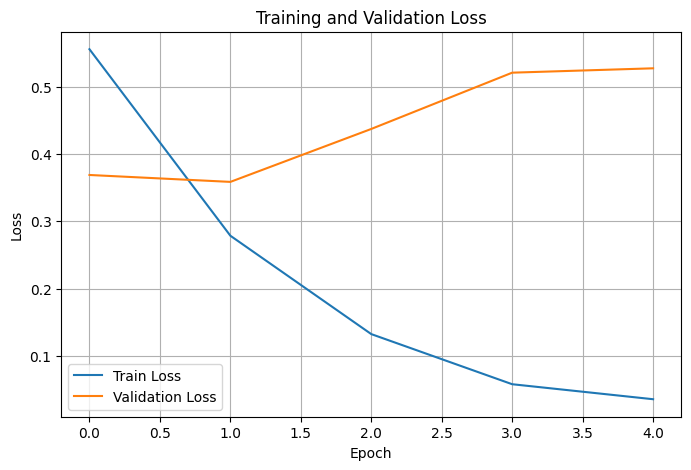

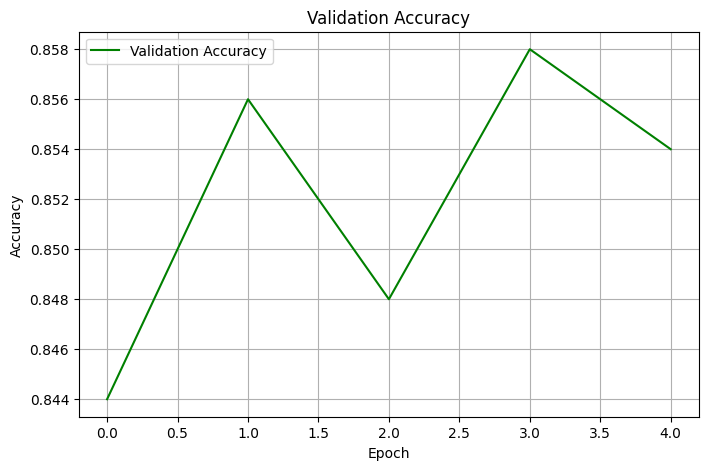

In [20]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history["val_acc"], label="Validation Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
checkpoint = torch.load(ckpt_path, map_location=device)

# Restore model and optimizer state
model.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optimizer_state"])

# Optionally restore epoch and val_acc
start_epoch = checkpoint["epoch"]
best_val_acc = checkpoint["val_acc"]

print(f"Loaded checkpoint from epoch {start_epoch} with val_acc={best_val_acc:.4f}")

Loaded checkpoint from epoch 4 with val_acc=0.8580


In [22]:
from sklearn.metrics import confusion_matrix
import numpy as np

def extended_evaluation(model, dataloader, device, num_examples=5):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    all_preds = []
    all_labels = []
    example_data = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item() * input_ids.size(0)
            preds = torch.argmax(logits, dim=-1).long()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            if len(example_data) < num_examples:
                for i in range(min(num_examples - len(example_data), input_ids.size(0))):
                    example_data.append({
                        "input_ids": input_ids[i].cpu().numpy(),
                        "true_label": labels[i].item(),
                        "pred_label": preds[i].item()
                    })

            total_correct += (preds == labels.long()).sum().item()
            total += input_ids.size(0)

    avg_loss = total_loss / total
    acc = total_correct / total

    conf_matrix = confusion_matrix(all_labels, all_preds)

    return avg_loss, acc, conf_matrix, example_data


def decode_input(input_ids, tokenizer):
    return tokenizer.decode(input_ids, skip_special_tokens=True)


loss, accuracy, confusion_mat, example_preds = extended_evaluation(model, test_loader, device, num_examples=5)

print("Loss on test set:", loss)
print("Accuracy on test set:", accuracy)
print("Confusion Matrix:\n", confusion_mat)

print("\nExample predictions:")
for i, example in enumerate(example_preds):
    decoded_input = decode_input(example["input_ids"], tokenizer)
    print(f"\nExample {i + 1}:")
    print(f"Input Text: {decoded_input}")
    print(f"True Label: {example['true_label']}")
    print(f"Predicted Label: {example['pred_label']}")

evaluating: 100%|██████████| 63/63 [00:06<00:00,  9.18it/s]

Loss on test set: 0.6348021557629109
Accuracy on test set: 0.826
Confusion Matrix:
 [[407  94]
 [ 80 419]]

Example predictions:

Example 1:
Input Text: unpretentious, charming, quirky, original
True Label: 1
Predicted Label: 1

Example 2:
Input Text: a film really has to be exceptional to justify a three hour running time, and this isn ' t.
True Label: 0
Predicted Label: 0

Example 3:
Input Text: working from a surprisingly sensitive script co - written by gianni romoli... ozpetek avoids most of the pitfalls you ' d expect in such a potentially sudsy set - up.
True Label: 1
Predicted Label: 1

Example 4:
Input Text: it may not be particularly innovative, but the film ' s crisp, unaffected style and air of gentle longing make it unexpectedly rewarding.
True Label: 1
Predicted Label: 1

Example 5:
Input Text: such a premise is ripe for all manner of lunacy, but kaufman and gondry rarely seem sure of where it should go.
True Label: 0
Predicted Label: 0
